### Introduction

Dans ce notebook, nous cherchons à construire un modèle de **Random Forest** pour prédire les prix des maisons, mais uniquement pour les maisons ayant un prix inférieur à **350 000 $**.

#### Méthodologie :
1. **Préprocessing des données** :
   - Nettoyage et préparation des données, encodage des variables non numériques.
   - Suppression des maisons dont le prix dépasse 350 000 $.

2. **Recherche d'hyperparamètres** :
   - **Randomized Search CV** : Une recherche rapide et efficace pour explorer de nombreux hyperparamètres sans effectuer de calculs exhaustifs.
   - **Grid Search CV** : Un affinement des meilleurs hyperparamètres issus de la recherche précédente pour trouver les combinaisons optimales.

3. **Adaptation des hyperparamètres** :
   - Réduction de l'overfitting en ajustant les hyperparamètres.
   - Utilisation des meilleurs hyperparamètres finaux pour entraîner un modèle performant et stable.

À la fin du notebook, nous évaluerons le modèle avec des courbes d'apprentissage pour analyser sa stabilité et son comportement en généralisation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [2]:
import sys
import os

# Ajouter le chemin du projet à sys.path pour que Python puisse trouver utils
sys.path.append('chemin_vers_le_projet/Housing_price_challenge')
import utils.data_utils as du
import utils.feature_selection as fs

In [3]:
from utils.data_utils import log_transformer

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
path = "chemin_vers_le_projet/Housing_price_challenge/home-data-for-ml-course/train.csv"

In [6]:
feature_list = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt', 'Neighborhood']

### Préprocessing des données

Dans cette partie, nous nettoyons et préparons les données :
- Transformation des variables non numériques en valeurs numériques avec un encodage ordinal.
- Suppression des maisons ayant un prix supérieur à **350 000 $**.
- Séparation des données en ensembles d'entraînement et de test.

In [7]:
houses = du.prep_data(path, delete_list=feature_list, delete_mode=False, replace='cat')
houses = du.bin_years_into_decades(houses, ['YearBuilt'])
houses = houses[houses['SalePrice'] <= 350000]
X = houses.drop('SalePrice', axis=1).copy()
y = houses['SalePrice'].copy()
X_train, X_test, y_train, y_test = train_test_split(X,
    y, 
    test_size=0.2, 
    random_state=42
)

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_selector

In [9]:
# Création d'une pipeline pour encoder les variables non numériques
preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(), make_column_selector(dtype_include=['object', 'category']))
    ],
    remainder='passthrough'  # Conserve les colonnes non transformées
)

# Pipeline complète avec préprocesseur
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Exemple d'utilisation avec les données d'entraînement
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal', OrdinalEncoder(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x16206b3d0>)])),
                ('model', RandomForestRegressor(random_state=42))])

### Randomized Search CV

Dans cette section, nous effectuons une recherche d'hyperparamètres à l'aide d'un **Randomized Search CV**. 
L'objectif est d'explorer efficacement un espace de recherche élargi pour identifier des combinaisons prometteuses sans tester toutes les possibilités.

In [10]:
from sklearn.model_selection import RandomizedSearchCV

In [11]:
# Grille élargie des hyperparamètres
param_distributions = {
    'model__max_depth': [None, 10, 12, 15, 20],  # Profondeur maximale pour éviter l'overfitting
    'model__max_features': ['sqrt', 'log2'],  # Contrôle du nombre de features utilisées à chaque split
    'model__min_samples_leaf': [1, 2, 3, 4, 5],  # Minimum de samples pour limiter l'overfitting
    'model__min_samples_split': [2, 5, 8, 10],  # Nombre minimum de samples pour diviser un noeud
    'model__n_estimators': [200, 500, 800, 1200, 1500]  # Nombre d'estimateurs pour une meilleure performance
}

# Randomized Search CV avec pipeline
random_search = RandomizedSearchCV(
    estimator=pipeline,  # Utilisation de la pipeline
    param_distributions=param_distributions,
    n_iter=50,  # Nombre d'itérations
    scoring='neg_mean_absolute_error',
    cv=5,  # Validation croisée
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Entraînement avec RandomizedSearchCV
random_search.fit(X_train, y_train)

# Affichage des meilleurs paramètres
print(f"Meilleurs hyperparamètres trouvés : {random_search.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END model__max_depth=12, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=500; total time=   0.7s
[CV] END model__max_depth=12, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=500; total time=   0.7s
[CV] END model__max_depth=12, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=500; total time=   0.8s
[CV] END model__max_depth=12, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=500; total time=   0.7s
[CV] END model__max_depth=12, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=2, model__n_estimators=500; total time=   0.8s
[CV] END model__max_depth=15, model__max_features=log2, model__min_samples_leaf=3, model__min_samples_split=2, model__n_estimators=200; total time=   0.3s
[CV] END

In [12]:
# Extraction et affichage des résultats du Randomized Search CV
results = pd.DataFrame(random_search.cv_results_)

# Affichage des résultats en utilisant les noms de colonnes corrects
display(results[['param_model__n_estimators', 
                 'param_model__max_depth', 
                 'param_model__min_samples_split', 
                 'param_model__min_samples_leaf', 
                 'mean_test_score', 
                 'rank_test_score']].sort_values('rank_test_score').head(10))

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,mean_test_score,rank_test_score
7,1200,12,8,1,-17361.643192,1
42,800,10,8,1,-17366.263416,2
32,500,15,2,2,-17379.554392,3
46,1500,20,2,2,-17382.382351,4
24,200,10,8,1,-17384.248356,5
4,500,12,8,1,-17384.401269,6
10,500,20,8,1,-17389.612829,7
47,500,15,2,1,-17392.676915,8
28,800,20,2,1,-17396.926013,9
26,500,None,2,1,-17397.664886,10


### Grid Search CV

Après avoir réduit l'espace de recherche avec le Randomized Search CV, nous effectuons un **Grid Search CV** pour affiner les hyperparamètres. 
Cette étape permet de trouver les meilleurs paramètres pour entraîner notre modèle.

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, roc_auc_score, roc_curve

In [14]:
# Grille resserrée autour des meilleurs hyperparamètres
param_grid = {
    'model__max_depth': [10, 12, 14],  # Contrôle la profondeur des arbres
    'model__max_features': ['sqrt'],   # Nombre de features utilisées à chaque split
    'model__min_samples_leaf': [2, 3, 4],  # Minimum de données par feuille
    'model__min_samples_split': [6, 8, 10],  # Minimum de données pour diviser un noeud
    'model__n_estimators': [1000, 1200, 1400]  # Nombre d'arbres dans la forêt
}

# GridSearchCV avec pipeline et scoring basé sur la MAE
grid_search = GridSearchCV(
    estimator=pipeline,  # Utilisation de la pipeline
    param_grid={
        'model__max_depth': [10, 12, 14],  # Autour de 12
        'model__max_features': ['sqrt'],  # Fixé à sqrt
        'model__min_samples_leaf': [2, 3, 4],  # Autour de 3
        'model__min_samples_split': [6, 8, 10],  # Autour de 8
        'model__n_estimators': [1000, 1200, 1400]  # Autour de 1200
    },
    scoring='neg_mean_absolute_error',  # Optimiser pour la MAE
    cv=5,  # 5-fold cross-validation
    verbose=2,
    n_jobs=-1
)

# Entraînement avec GridSearchCV
grid_search.fit(X_train, y_train)

# Affichage des meilleurs paramètres
print(f"Meilleurs paramètres : {grid_search.best_params_}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=6, model__n_estimators=1000; total time=   1.4s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=6, model__n_estimators=1000; total time=   1.4s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=6, model__n_estimators=1000; total time=   1.5s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=6, model__n_estimators=1000; total time=   1.5s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=6, model__n_estimators=1000; total time=   1.5s
[CV] END model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=6, model__n_estimators=1200; total time=   1.8s
[C

### Meilleur modèle et courbes d'apprentissage

À l'aide des meilleurs hyperparamètres trouvés, nous entraînons le modèle final et évaluons sa performance. 
Nous utilisons des **courbes d'apprentissage** basées sur le R² pour analyser le comportement du modèle et détecter un éventuel overfitting ou underfitting.

In [17]:
# Extraction et affichage des résultats du GridSearchCV
results = pd.DataFrame(grid_search.cv_results_)

# Affichage des résultats avec les noms de colonnes compatibles avec la pipeline
display(results[['param_model__n_estimators', 
                 'param_model__max_depth', 
                 'param_model__min_samples_split', 
                 'param_model__min_samples_leaf', 
                 'mean_test_score', 
                 'rank_test_score']].sort_values('rank_test_score').head(20))

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,mean_test_score,rank_test_score
28,1200,12,6,2,-17401.696559,1
27,1000,12,6,2,-17410.352707,2
29,1400,12,6,2,-17412.161594,3
2,1400,10,6,2,-17416.648863,4
0,1000,10,6,2,-17419.431462,5
1,1200,10,6,2,-17419.764025,6
56,1400,14,6,2,-17422.358249,7
55,1200,14,6,2,-17430.142785,8
54,1000,14,6,2,-17432.967462,9
32,1400,12,8,2,-17454.303219,10


R² (train) : 0.9288
R² (test) : 0.8221


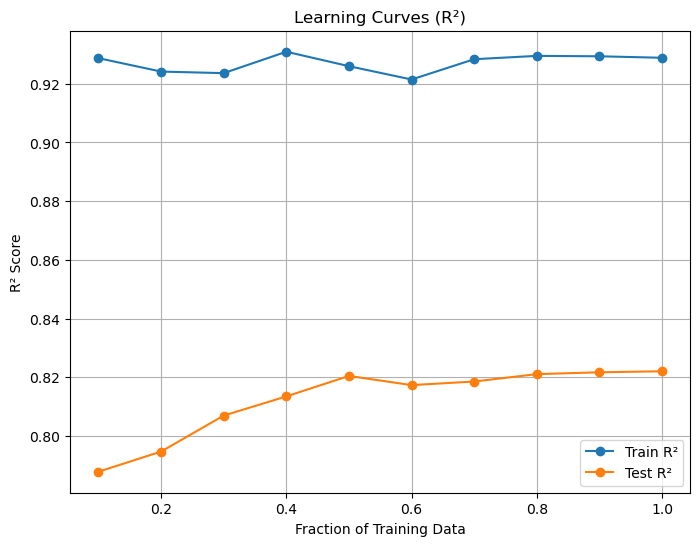

In [16]:
# Meilleur modèle
best_pipeline = grid_search.best_estimator_  # Utilisation de la pipeline optimisée

# Calcul des prédictions pour train et test
y_train_pred = best_pipeline.predict(X_train)
y_test_pred = best_pipeline.predict(X_test)

# R² pour train et test
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Affichage des résultats
print(f"R² (train) : {train_r2:.4f}")
print(f"R² (test) : {test_r2:.4f}")

# Courbes de validation
train_sizes = np.linspace(0.1, 1.0, 10)
train_scores, test_scores = [], []

for train_size in train_sizes:
    subset_idx = int(len(X_train) * train_size)
    X_subset, y_subset = X_train[:subset_idx], y_train[:subset_idx]
    # Refit la pipeline pour chaque fraction des données
    best_pipeline.fit(X_subset, y_subset)
    train_scores.append(r2_score(y_subset, best_pipeline.predict(X_subset)))
    test_scores.append(r2_score(y_test, best_pipeline.predict(X_test)))

# Affichage des courbes
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores, label="Train R²", marker='o')
plt.plot(train_sizes, test_scores, label="Test R²", marker='o')
plt.xlabel("Fraction of Training Data")
plt.ylabel("R² Score")
plt.title("Learning Curves (R²)")
plt.legend()
plt.grid()
plt.show()

R² (train) : 0.9084
R² (test) : 0.8192


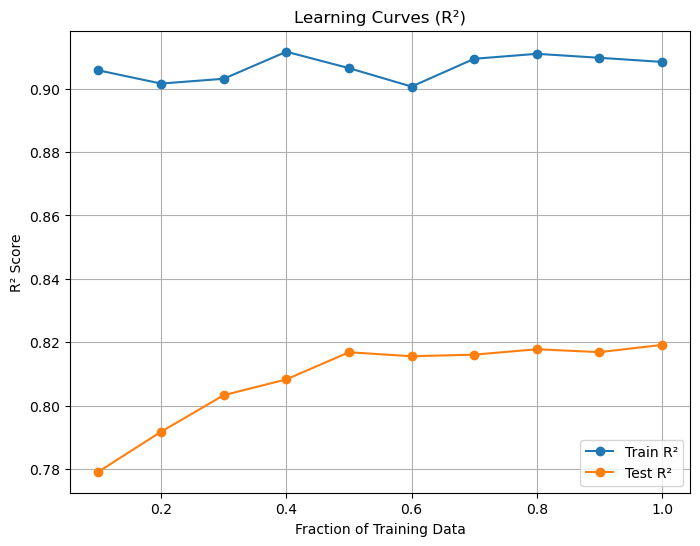

In [19]:
# Définir les hyperparamètres
rf_best_params = {
    'max_depth': 10,
    'max_features': 'sqrt',
    'min_samples_leaf': 3,
    'min_samples_split': 8,
    'n_estimators': 1200
}

# Configurer la pipeline avec les meilleurs hyperparamètres
pipeline.set_params(model__max_depth=rf_best_params['max_depth'],
                    model__max_features=rf_best_params['max_features'],
                    model__min_samples_leaf=rf_best_params['min_samples_leaf'],
                    model__min_samples_split=rf_best_params['min_samples_split'],
                    model__n_estimators=rf_best_params['n_estimators'])

# Entraîner le modèle avec les données d'entraînement
pipeline.fit(X_train, y_train)

# Calcul des prédictions pour train et test
y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

# Évaluer le modèle avec R²
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Affichage des scores
print(f"R² (train) : {train_r2:.4f}")
print(f"R² (test) : {test_r2:.4f}")

# Courbes d'apprentissage
train_sizes = np.linspace(0.1, 1.0, 10)
train_scores, test_scores = [], []

for train_size in train_sizes:
    subset_idx = int(len(X_train) * train_size)
    X_subset, y_subset = X_train[:subset_idx], y_train[:subset_idx]
    pipeline.fit(X_subset, y_subset)
    train_scores.append(r2_score(y_subset, pipeline.predict(X_subset)))
    test_scores.append(r2_score(y_test, pipeline.predict(X_test)))

# Affichage des courbes
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores, label="Train R²", marker='o')
plt.plot(train_sizes, test_scores, label="Test R²", marker='o')
plt.xlabel("Fraction of Training Data")
plt.ylabel("R² Score")
plt.title("Learning Curves (R²)")
plt.legend()
plt.grid()
plt.show()

### Conclusion

Dans ce notebook, nous avons construit un modèle de **Random Forest** capable de prédire les prix des maisons en dessous de **350 000 $**. Voici les étapes principales et les observations finales :

1. **Préprocessing** :
   - Les données ont été nettoyées et transformées, et les maisons les plus chères ont été exclues pour concentrer l'analyse sur un sous-ensemble cohérent.
   
2. **Recherche d'hyperparamètres** :
   - Un **Randomized Search CV** a permis d'explorer efficacement un espace de recherche élargi pour identifier des combinaisons prometteuses.
   - Un **Grid Search CV** a affiné les hyperparamètres pour améliorer la performance.

3. **Modèle final** :
   - Les meilleurs hyperparamètres finaux ont été utilisés pour entraîner le modèle.
   - Les **courbes d'apprentissage** montrent un potentiel d'amélioration mais révèlent également un certain overfitting, soulignant les défis liés à l'adaptation précise des hyperparamètres.

#### Limitations et pistes d'amélioration :
- Le choix d'un modèle basé sur les ensembles, comme la Random Forest, était motivé par la présence d'outliers dans les données, qui ne pouvaient pas être éliminés pour le concours.
- Les modèles linéaires ont été écartés en raison de la nature non linéaire des données.
- Le **gradient boosting**, bien qu'intéressant, aurait probablement souffert des mêmes problèmes de surapprentissage sans une recherche d'hyperparamètres approfondie.
- Une recherche plus longue et itérative des hyperparamètres, avec plusieurs passes de **Randomized Search CV**, aurait pu permettre de réduire davantage l'overfitting et d'optimiser les performances.

Ce projet illustre l'importance d'une **approche itérative** pour construire des modèles robustes et adaptés aux données. Bien que l'overfitting soit visible, les résultats obtenus montrent des performances prometteuses et offrent une base solide pour poursuivre le travail.